# 🎵 Music Generation with an LSTM — Google Colab

This notebook is a **workable, simplified version of the MIT Deep Learning Music Generation lab**.

### What we will build

```text
Irish folk songs
      ↓
ABC text
      ↓
Characters → integer IDs
      ↓
Input sequence + target sequence
      ↓
Embedding
      ↓
LSTM
      ↓
Linear layer
      ↓
Next-character probabilities
      ↓
Cross-Entropy Loss
      ↓
Backpropagation + Adam
      ↓
Trained LSTM
      ↓
Seed text
      ↓
Generate characters one-by-one
      ↓
New ABC music
```

> **Important:** The model learns to generate **ABC music notation**, not raw audio. We will also try to render the generated ABC notation as MIDI/audio when the required tools are available.


## 1. Install and import everything

This cell installs the small set of packages we need and imports PyTorch and utilities.


In [1]:
!pip -q install music21 requests

import os
import re
import math
import random
import urllib.request
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


PyTorch version: 2.11.0+cu130
CUDA available: True
Using device: cuda


## 2. Download the Irish folk-song dataset

We use the same general type of dataset used in the MIT lab: songs represented as **ABC notation**.

ABC notation is text. For example:

```text
X:1
T:Example
M:4/4
K:G
GABc|d2cB|...
```

The neural network will learn patterns in these characters.


In [4]:
# ============================================================
# LOAD THE OFFICIAL MIT IRISH FOLK MUSIC DATASET
# ============================================================

import urllib.request

DATA_URL = "https://raw.githubusercontent.com/MITDeepLearning/introtodeeplearning/master/mitdeeplearning/data/irish.abc"
DATA_FILE = "/content/irish.abc"

print("Downloading official MIT Irish folk music dataset...")

urllib.request.urlretrieve(DATA_URL, DATA_FILE)

print("✅ Download successful!")
print("File:", DATA_FILE)

# Read the ABC music data
with open(DATA_FILE, "r", encoding="utf-8") as f:
    songs_text = f.read()

print("✅ Dataset loaded successfully!")
print("Number of characters:", len(songs_text))

print("\nFirst 1000 characters:\n")
print(songs_text[:1000])


✅ Download successful!
File: /content/irish.abc
✅ Dataset loaded successfully!
Number of characters: 197618

First 1000 characters:

X:1
T:Alexander's
Z: id:dc-hornpipe-1
M:C|
L:1/8
K:D Major
(3ABc|dAFA DFAd|fdcd FAdf|gfge fefd|(3efe (3dcB A2 (3ABc|!
dAFA DFAd|fdcd FAdf|gfge fefd|(3efe dc d2:|!
AG|FAdA FAdA|GBdB GBdB|Acec Acec|dfaf gecA|!
FAdA FAdA|GBdB GBdB|Aceg fefd|(3efe dc d2:|!

X:2
T:An Buachaill Dreoite
Z: id:dc-hornpipe-2
M:C|
L:1/8
K:G Major
GF|DGGB d2GB|d2GF Gc (3AGF|DGGB d2GB|dBcA F2GF|!
DGGB d2GF|DGGF G2Ge|fgaf gbag|fdcA G2:|!
GA|B2BG c2cA|d2GF G2GA|B2BG c2cA|d2DE F2GA|!
B2BG c2cA|d^cde f2 (3def|g2gf gbag|fdcA G2:|!

X:3
T:Belfast
Z: id:dc-hornpipe-3
M:C|
L:1/8
K:D Major
ag|(3faf df AdFA|DFAd f2ef|gbec dfAF|GABG E2ag|!
(3faf df AdFA|DFAd f2ef|gbed cABc|d2f2 d2:|!
(3DEF|GFGA Bcde|fgfe dcdB|A2f2 fef2|G2e2 ede2|!
GFGA Bcde|fgfe dcdB|Afed cABc|d2f2 d2:|!
ag|(3fgf (3efe (3ded (3cdc|(3BcB (3ABA G2ba|(3gag (3fgf (3efe (3ded|(3cdc (3BcB A2ag|!
(3fgf (3efe (3ded (3cdc|(3BcB (3ABA (3

## 3. Understand the data

The most important idea is:

**The model does not see "music" directly. It sees text characters.**

For example:

```text
X:1
T:My Song
M:4/4
K:G
GABc|d2cB|
```

becomes a sequence of characters:

```text
X : 1 \n T : M y ...
```

We create a vocabulary containing every unique character.


In [5]:
# Create vocabulary
vocab = sorted(set(songs_text))

vocab_size = len(vocab)

char2idx = {char: idx for idx, char in enumerate(vocab)}
idx2char = {idx: char for idx, char in enumerate(vocab)}

print("Vocabulary size:", vocab_size)
print("Vocabulary:")
print(vocab)

# Convert all characters into integer IDs
encoded_text = torch.tensor([char2idx[c] for c in songs_text], dtype=torch.long)

print("\nFirst 100 characters:")
print(repr(songs_text[:100]))

print("\nFirst 100 integer IDs:")
print(encoded_text[:100].tolist())


Vocabulary size: 83
Vocabulary:
['\n', ' ', '!', '"', '#', "'", '(', ')', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', '<', '=', '>', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', ']', '^', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '|']

First 100 characters:
"X:1\nT:Alexander's\nZ: id:dc-hornpipe-1\nM:C|\nL:1/8\nK:D Major\n(3ABc|dAFA DFAd|fdcd FAdf|gfge fefd|(3efe"

First 100 integer IDs:
[49, 22, 13, 0, 45, 22, 26, 67, 60, 79, 56, 69, 59, 60, 73, 5, 74, 0, 51, 22, 1, 64, 59, 22, 59, 58, 9, 63, 70, 73, 69, 71, 64, 71, 60, 9, 13, 0, 38, 22, 28, 82, 0, 37, 22, 13, 11, 20, 0, 36, 22, 29, 1, 38, 56, 65, 70, 73, 0, 6, 15, 26, 27, 58, 82, 59, 26, 31, 26, 1, 29, 31, 26, 59, 82, 61, 59, 58, 59, 1, 31, 26, 59, 61, 82, 62, 61, 62, 60, 1, 61, 60, 61, 59, 82, 6, 15, 60, 61, 60]


## 4. The most important training idea: input and target

Suppose the text is:

```text
HELLO
```

We want the model to learn:

```text
Input:  H E L L
Target: E L L O
```

In other words:

> Given the current character/context, predict what comes next.

For a longer sequence:

```text
Input:   X : 1 \n T : E x
Target:  : 1 \n T : x a
```

The target is simply the input shifted **one character to the left**.


In [6]:
def get_batch(data, batch_size=8, seq_length=100):
    max_start = len(data) - seq_length - 1
    starts = torch.randint(0, max_start, (batch_size,))

    x = torch.stack([data[i:i+seq_length] for i in starts])
    y = torch.stack([data[i+1:i+seq_length+1] for i in starts])

    return x.to(device), y.to(device)

x, y = get_batch(encoded_text, batch_size=2, seq_length=20)

print("Input shape :", x.shape)
print("Target shape:", y.shape)

print("\nInput:")
print("".join(idx2char[i.item()] for i in x[0]))

print("\nTarget:")
print("".join(idx2char[i.item()] for i in y[0]))


Input shape : torch.Size([2, 20])
Target shape: torch.Size([2, 20])

Input:
cd|fed cAF|AGF G2A:|

Target:
d|fed cAF|AGF G2A:|!


## 5. Build the LSTM model

The model has only three major parts:

```text
Integer character ID
       ↓
Embedding
       ↓
LSTM
       ↓
Linear
       ↓
Scores for every possible next character
```

### Embedding

Turns a character ID such as `17` into a learned vector.

### LSTM

Reads the sequence and maintains information about previous characters.

### Linear layer

Converts the LSTM output into one score for every possible character.

If the vocabulary has 80 characters, the final output at each position has **80 scores**.


In [7]:
class MusicLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_size=256):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, state=None):
        # x: [batch, sequence_length]
        embedded = self.embedding(x)

        # embedded: [batch, sequence_length, embedding_dim]
        output, state = self.lstm(embedded, state)

        # output: [batch, sequence_length, hidden_size]
        logits = self.linear(output)

        # logits: [batch, sequence_length, vocab_size]
        return logits, state

    def init_hidden(self, batch_size):
        h = torch.zeros(1, batch_size, self.lstm.hidden_size, device=device)
        c = torch.zeros(1, batch_size, self.lstm.hidden_size, device=device)
        return (h, c)


model = MusicLSTM(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_size=256
).to(device)

print(model)

total_params = sum(p.numel() for p in model.parameters())
print("\nTotal parameters:", f"{total_params:,}")


MusicLSTM(
  (embedding): Embedding(83, 128)
  (lstm): LSTM(128, 256, batch_first=True)
  (linear): Linear(in_features=256, out_features=83, bias=True)
)

Total parameters: 427,219


## 6. See the tensor shapes

This is a very useful debugging/learning cell.

If:

```text
batch_size = 2
sequence_length = 20
embedding_dim = 128
hidden_size = 256
vocab_size = N
```

then:

```text
Input       → [2, 20]
Embedding   → [2, 20, 128]
LSTM        → [2, 20, 256]
Linear      → [2, 20, N]
```

The last dimension contains a score for every possible next character.


In [8]:
with torch.no_grad():
    sample_x, _ = get_batch(encoded_text, batch_size=2, seq_length=20)

    embedded = model.embedding(sample_x)
    lstm_out, state = model.lstm(embedded)
    logits = model.linear(lstm_out)

print("Input shape      :", sample_x.shape)
print("Embedding shape  :", embedded.shape)
print("LSTM output shape:", lstm_out.shape)
print("Logits shape     :", logits.shape)


Input shape      : torch.Size([2, 20])
Embedding shape  : torch.Size([2, 20, 128])
LSTM output shape: torch.Size([2, 20, 256])
Logits shape     : torch.Size([2, 20, 83])


## 7. Loss function

The model produces **logits**.

For each position it might say:

```text
A → 0.05
B → 0.10
C → 0.02
D → 0.70  ← model's strongest prediction
...
```

But suppose the correct next character is `B`.

The loss will be high because the model gave `B` a low probability.

Cross-entropy loss tells the model:

> "Your prediction was wrong by this much."

Then backpropagation calculates how the parameters should change.


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

x, y = get_batch(encoded_text, batch_size=4, seq_length=50)

logits, _ = model(x)

# logits: [B, L, V]
# target : [B, L]

# CrossEntropyLoss expects:
# predictions [N, C]
# targets     [N]
loss = criterion(
    logits.reshape(-1, vocab_size),
    y.reshape(-1)
)

print("Logits shape:", logits.shape)
print("Loss:", loss.item())


Logits shape: torch.Size([4, 50, 83])
Loss: 4.428484916687012


## 8. One complete training step

This is the heart of neural-network training:

```text
1. Get input + target
2. Forward pass
3. Calculate loss
4. Backpropagation
5. Update weights
```

This happens thousands of times.


In [10]:
def train_step(model, optimizer, criterion, data, batch_size=8, seq_length=100):
    model.train()

    x, y = get_batch(data, batch_size, seq_length)

    optimizer.zero_grad()

    logits, _ = model(x)

    loss = criterion(
        logits.reshape(-1, vocab_size),
        y.reshape(-1)
    )

    loss.backward()

    # Helps prevent exploding gradients in recurrent networks
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    optimizer.step()

    return loss.item()


## 9. Train the model

For learning purposes, the default below is intentionally modest.

You can increase:

```python
NUM_STEPS = 3000
```

later for better music.

A GPU is strongly recommended for the longer run.


In [11]:
NUM_STEPS = 800
BATCH_SIZE = 16
SEQ_LENGTH = 100
PRINT_EVERY = 100

# Reinitialize model so this cell always starts a fresh training run
model = MusicLSTM(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_size=256
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
criterion = nn.CrossEntropyLoss()

loss_history = []

print("Starting training...")
print("Device:", device)

for step in range(1, NUM_STEPS + 1):
    loss = train_step(
        model,
        optimizer,
        criterion,
        encoded_text,
        batch_size=BATCH_SIZE,
        seq_length=SEQ_LENGTH
    )

    loss_history.append(loss)

    if step == 1 or step % PRINT_EVERY == 0:
        print(f"Step {step:4d}/{NUM_STEPS} | Loss: {loss:.4f}")

print("Training complete.")


Starting training...
Device: cuda
Step    1/800 | Loss: 4.4376
Step  100/800 | Loss: 1.3656
Step  200/800 | Loss: 1.2804
Step  300/800 | Loss: 1.2137
Step  400/800 | Loss: 1.1264
Step  500/800 | Loss: 1.0835
Step  600/800 | Loss: 1.0102
Step  700/800 | Loss: 1.1002
Step  800/800 | Loss: 1.0000
Training complete.


## 10. Plot the training loss

Ideally, the loss should decrease as the model learns.


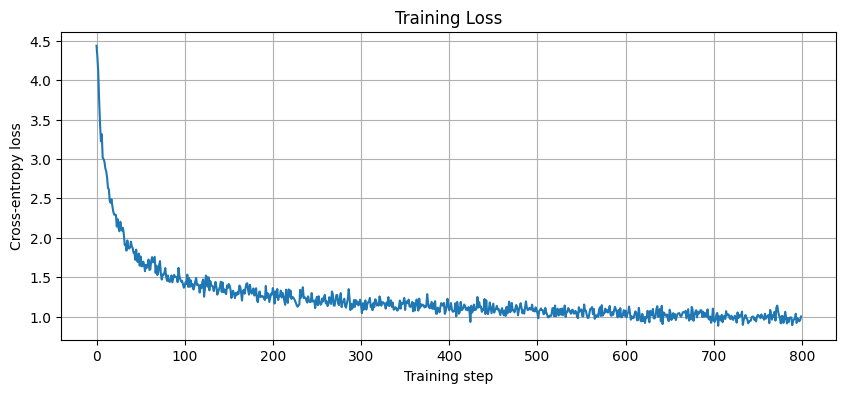

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(loss_history)
plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()


## 11. Generate music

Now training is finished.

We give the model a small **seed**:

```text
X
```

Then:

```text
X → predict next character
X: → predict next character
X:1 → predict next character
X:1\n → predict next character
...
```

The predicted character is fed back into the model.

This is called **autoregressive generation**.


In [13]:
@torch.no_grad()
def generate_text(
    model,
    seed="X",
    num_chars=1000,
    temperature=0.8
):
    model.eval()

    # Convert seed characters to IDs
    input_ids = torch.tensor(
        [[char2idx[c] for c in seed]],
        dtype=torch.long,
        device=device
    )

    state = None
    generated = seed

    for _ in range(num_chars):
        logits, state = model(input_ids, state)

        # Only need the prediction for the final character
        next_logits = logits[:, -1, :] / temperature

        probabilities = F.softmax(next_logits, dim=-1)

        # Randomly sample according to probabilities
        next_id = torch.multinomial(probabilities, num_samples=1)

        next_char = idx2char[next_id.item()]
        generated += next_char

        # Feed generated character back in
        input_ids = next_id

    return generated


generated_abc = generate_text(
    model,
    seed="X",
    num_chars=1500,
    temperature=0.8
)

print(generated_abc)


X:122
T:Sandy Kelly's
Z: id:dc-reel-277
M:C
L:1/8
K:G Major
(3DEF|G2BG EGBG|AcBA G3G|FDD2 CDB,D|cEBE cEcE|!
ADAD BDAD|FDFG FEFD|EdcA G3:|[2 AcA^c dcBc|dGG2 G2:|!
Bc|dgg2 gfga|bgag fded|cAGE EDD2|!

X:30
T:Trip to Craidy
Z: id:dc-jig-13
M:6/8
L:1/8
K:A Major
E3 BAB|cBc A2f e2A|E3 ADB AFD2|E3 E2 G3|B3 E D2|]!
B3 c B2|E> GF EF|G2F ED|C2 E2|!
[1 F G2|F2 F2 FA|E3 FE D2|F2 F2 E2|!
F3 F EF|G2 B2 GB|A2 F2 E2|FD F2 A2|F2 A2 d2|cB AF FE|!
d3 B B2|d2 d2 dc|B2 F2 AF|G3 A BE|E2 c2 Bc|!
d3 dB AF|EF BF F2|A2 F2 E2|F2 D2 F2|A2 F2 A2|!
d4 f2|d4|c2 A2 G2|A2 d2 f2|A2 D2 F2|E2 c2 C>G|F2 D2 D2:|!
fB B2 A2|B4 AF|E2 E2 F2|G2 F2 F2|D4 E2|!
B3 B AF|GB dB AF|D3 D D2:|!
A2 Bc d2|F2 d3 c2|A3 G F2|F2 AF D2|!
d3 f e3|f2 d2 d2|=cA A>B|c2 A2 c2|d4 f|g2 a2 ba|!
g2 f3 g3|a3 ba a2|g2 b2 g2|f2 f2 f2|!
d2 e f2|d2 ef gf|eg e2 c2|B4 G3:|!
A>B AF/|A>B cA|BG G2:|!

X:7
T:Chomen Failling int the Kille
Z: id:dc-reel-345
M:C
L:1/8
K:G Major
D|G2Bd edgd|BGBd edBd|g2fg efge|dBGB ABAG|!
FEFG AFFE|FGAF DFF2|G2Bd defd|cded cAAG|!
FGA

## 12. Temperature

Temperature controls how conservative or creative the generation is.

```text
Low temperature
    ↓
More predictable
More repetitive

High temperature
    ↓
More random
More creative
Potentially more chaotic
```

Try values such as:

```python
0.5
0.8
1.0
1.2
```


In [14]:
for temperature in [0.5, 0.8, 1.0]:
    print("\n" + "="*80)
    print("TEMPERATURE:", temperature)
    print("="*80)

    sample = generate_text(
        model,
        seed="X",
        num_chars=500,
        temperature=temperature
    )

    print(sample)



TEMPERATURE: 0.5
X:157
T:Treen the Mounter
Z: id:dc-reel-177
M:C
L:1/8
K:E Dorian
AB|c2Ac B2AB|cBAF ABcA|B2cB A2Bc|d2cd BAFA|BAFA FA:|!

X:262
T:Maids of to the Road
Z: id:dc-polka-37
M:2/4
L:1/8
K:A Major
e|f3 fed|B3 B3|A3 A3|d3 d3|!
c3 d3|edB ABA|G3 FED:|!

X:24
T:Sheip to Windon
Z: id:dc-reel-33
M:C
L:1/8
K:A Major
E|FDFD DFGA|BABd edBd|cAdB ABde|fdd2 fdd2|!
FABd efge|fedf edBA|d2fd edBd|A2FA BAFA|BdBA F3:|!
A|Bdd2 BAFA|defd edBd|AdBA FAdB|AFF2 ABde|f2dB AFAB|!
dcBA FABd|e2cd ecAF|E2E2 E2BE|ABde f2ed|c2BA F2AF

TEMPERATURE: 0.8
X:234
T:Rodig the Trair
Z: id:dc-reel-210
M:C
L:1/8
K:B Minoly
Z: id:dc-reel-362
M:C
L:1/8
K:D Mixolydian
ed|cABG AGEG|G2ea agef|gedB G2Bd|g2fg agfg|afdf bgag|fdcA BGcG|!
ABAG FDDg|fedc ABdf|e2dc BGG2|]!

X:27
T:Blach in the Stl
Z: id:dc-reel-10
M:C
L:1/8
K:A Dorian
B,E|FEE E2B|ABA AFA|BAB dBA|BAF Bcd|!
e3 d3|B3 AFE|F2d fdf|edB BAF|BdB AFA|!
Bee efg|f3 fed|fed edB|ABA FAd|!
Add fdd|edB A2F|ABA FAd|FGA B2A|!
FBB B2B BAG|F3 AFA B2A|B2B BAF E2A|B3 Bcd|edB BAF|F

## 13. Try to extract individual ABC songs

The model may generate several song headers. We can inspect the generated text and look for `X:` markers.


In [15]:
def split_abc_songs(text):
    positions = [m.start() for m in re.finditer(r"(?m)^X:", text)]

    if not positions:
        return [text]

    songs = []

    for i, start in enumerate(positions):
        end = positions[i + 1] if i + 1 < len(positions) else len(text)
        song = text[start:end].strip()

        if len(song) > 30:
            songs.append(song)

    return songs


generated_songs = split_abc_songs(generated_abc)

print("Number of detected song sections:", len(generated_songs))

for i, song in enumerate(generated_songs[:3]):
    print(f"\n--- SONG {i+1} ---")
    print(song[:1000])


Number of detected song sections: 5

--- SONG 1 ---
X:122
T:Sandy Kelly's
Z: id:dc-reel-277
M:C
L:1/8
K:G Major
(3DEF|G2BG EGBG|AcBA G3G|FDD2 CDB,D|cEBE cEcE|!
ADAD BDAD|FDFG FEFD|EdcA G3:|[2 AcA^c dcBc|dGG2 G2:|!
Bc|dgg2 gfga|bgag fded|cAGE EDD2|!

--- SONG 2 ---
X:30
T:Trip to Craidy
Z: id:dc-jig-13
M:6/8
L:1/8
K:A Major
E3 BAB|cBc A2f e2A|E3 ADB AFD2|E3 E2 G3|B3 E D2|]!
B3 c B2|E> GF EF|G2F ED|C2 E2|!
[1 F G2|F2 F2 FA|E3 FE D2|F2 F2 E2|!
F3 F EF|G2 B2 GB|A2 F2 E2|FD F2 A2|F2 A2 d2|cB AF FE|!
d3 B B2|d2 d2 dc|B2 F2 AF|G3 A BE|E2 c2 Bc|!
d3 dB AF|EF BF F2|A2 F2 E2|F2 D2 F2|A2 F2 A2|!
d4 f2|d4|c2 A2 G2|A2 d2 f2|A2 D2 F2|E2 c2 C>G|F2 D2 D2:|!
fB B2 A2|B4 AF|E2 E2 F2|G2 F2 F2|D4 E2|!
B3 B AF|GB dB AF|D3 D D2:|!
A2 Bc d2|F2 d3 c2|A3 G F2|F2 AF D2|!
d3 f e3|f2 d2 d2|=cA A>B|c2 A2 c2|d4 f|g2 a2 ba|!
g2 f3 g3|a3 ba a2|g2 b2 g2|f2 f2 f2|!
d2 e f2|d2 ef gf|eg e2 c2|B4 G3:|!
A>B AF/|A>B cA|BG G2:|!

--- SONG 3 ---
X:7
T:Chomen Failling int the Kille
Z: id:dc-reel-345
M:C
L:1/8
K:G Major
D|G2Bd 

## 14. Optional: save the generated ABC text

You can download the generated notation and use it with an ABC music player/editor.


In [ ]:
ABC_FILE = "/content/generated_music.abc"

with open(ABC_FILE, "w", encoding="utf-8") as f:
    f.write(generated_abc)

print("Saved:", ABC_FILE)

from google.colab import files
files.download(ABC_FILE)


## 15. Optional: render ABC notation with Music21

This attempts to convert the generated ABC notation into MIDI.

Because generated text is not guaranteed to be valid ABC notation, this step may fail. That is normal during experimentation.


In [ ]:
from music21 import converter

MIDI_FILE = "/content/generated_music.mid"

try:
    # Try parsing the generated ABC
    score = converter.parse(generated_abc, format="abc")

    score.write("midi", fp=MIDI_FILE)

    print("MIDI created:", MIDI_FILE)

except Exception as e:
    print("Music rendering failed.")
    print("This usually means the generated ABC notation is malformed.")
    print("Error:", type(e).__name__, str(e)[:500])


## 16. Download MIDI if it was created

If the previous cell succeeded, run this cell.


In [ ]:
if os.path.exists("/content/generated_music.mid"):
    from google.colab import files
    files.download("/content/generated_music.mid")
else:
    print("No MIDI file was created.")


# 🧠 What you just built

The complete system is:

```text
                    TRAINING
                       │
                       ▼
             Thousands of songs
                       │
                       ▼
                  ABC text
                       │
                       ▼
             Character → ID
                       │
                       ▼
              Input + Target
                 │         │
                 ▼         ▼
             Embedding    Correct
                 │         │
                 ▼         │
                LSTM       │
                 │         │
                 ▼         │
              Linear       │
                 │         │
                 ▼         │
            Prediction ────┘
                 │
                 ▼
          Cross Entropy Loss
                 │
                 ▼
            Backpropagation
                 │
                 ▼
             Adam updates
                 │
                 └─────── repeat
                          │
                          ▼
                    TRAINED LSTM


                    GENERATION
                       │
                       ▼
                     "X"
                       │
                       ▼
                  LSTM predicts
                       │
                       ▼
                     ":"
                       │
                       ▼
                Feed ":" back
                       │
                       ▼
                     "1"
                       │
                       ▼
                Feed "1" back
                       │
                       ▼
                  next character
                       │
                       ▼
                      ...
                       │
                       ▼
                Generated ABC
                       │
                       ▼
                 MIDI / audio
```

## The single most important concept

The model is learning:

**"Given everything I have seen so far, what character is likely to come next?"**

That is the same fundamental idea behind modern language models:

```text
LSTM music model
→ predict next CHARACTER

GPT-style language model
→ predict next TOKEN
```

The architecture and scale are very different, but the next-step prediction idea is closely related.
